# 07 · Preference learning, DPO, and simplified GRPO

[Course README](../README.md) · README topics **36–39**

**Goal.** Fit a reward model to comparisons, optimize preferences directly with DPO, and implement group-relative policy updates in a fully inspectable categorical setting.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/grpo-training.svg" width="760" alt="Overview of Preference learning, DPO, and simplified GRPO">

## 1. What this experiment does and does not model

Three synthetic prompts each have four candidate responses. A table of hidden utility scores
generates noisy pairwise preferences and scores online samples. The policy is a tiny table of
trainable logits, one categorical distribution per prompt. An action is an **entire response**;
each episode lasts one step, so no value bootstrap or token-level credit assignment is needed.

**Analogy:** an editor compares several drafts for the same assignment. A reward model learns
the editor's rankings; DPO uses draft pairs directly; the group-relative experiment samples new
drafts and compares their scores within each assignment.

This notebook does **not** train a language model or use real human judgments. Its synthetic
utilities are known for evaluation and its categorical KL can be computed exactly. It exposes
the objectives and update mechanics, but cannot establish reasoning capability, real-world
alignment, or the performance of a production GRPO implementation.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

import torch
from torch import nn
from torch.distributions import Categorical

# These tiny examples run on CPU; a single thread avoids thread-launch overhead.
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

Python 3.12.4 | NumPy 1.26.4


PyTorch 2.11.0+cu130 | device: cpu


In [2]:
PROMPTS = ['Explain a concept', 'Solve a small problem', 'Choose a useful tool']
RESPONSES = ['Candidate A', 'Candidate B', 'Candidate C', 'Candidate D']
UTILITY = torch.tensor([[0.0, 1.0, 2.0, -1.0],
                        [2.0, -1.0, 0.0, 1.0],
                        [-1.0, 2.0, 1.0, 0.0]])
REFERENCE_LOGITS = torch.tensor([[0.2, 0.0, -0.2, 0.1],
                                 [0.0, 0.1, 0.2, -0.2],
                                 [-0.1, 0.2, 0.0, 0.1]])
REFERENCE_LOGP = REFERENCE_LOGITS.log_softmax(dim=-1).detach()
N_PROMPTS, N_RESPONSES = UTILITY.shape

def sample_preferences(n, seed):
    """Independently sample noisy Bradley–Terry comparisons from a known utility table."""
    rng = np.random.default_rng(seed)
    prompts, winners, losers = [], [], []
    for _ in range(n):
        prompt = int(rng.integers(N_PROMPTS))
        a, b = rng.choice(N_RESPONSES, size=2, replace=False)
        p_a_wins = torch.sigmoid(UTILITY[prompt, a] - UTILITY[prompt, b]).item()
        winner, loser = (a, b) if rng.random() < p_a_wins else (b, a)
        prompts.append(prompt); winners.append(winner); losers.append(loser)
    return tuple(torch.tensor(x, dtype=torch.long) for x in [prompts, winners, losers])

train_pairs = sample_preferences(600, seed=7)
test_pairs = sample_preferences(300, seed=2026)
print('Training comparisons:', len(train_pairs[0]), '| held-out comparison draws:', len(test_pairs[0]))
print('Hidden utility table:\n', UTILITY.numpy())

Training comparisons: 600 | held-out comparison draws: 300
Hidden utility table:
 [[ 0.  1.  2. -1.]
 [ 2. -1.  0.  1.]
 [-1.  2.  1.  0.]]


## 2. Fit a pairwise reward model

For preferred and rejected responses, the Bradley–Terry model predicts
`P(preferred wins) = sigmoid(score_preferred - score_rejected)`. We minimize negative log
probability using `logsigmoid`, which is more numerically stable than taking the log of an
already-computed sigmoid. Only score differences are identified: adding a constant to all
responses for one prompt does not change any comparison probability.

Train and test labels are independent draws from the same finite prompt/response space.
This is a test of ranking estimation under label noise, **not** generalization to unseen prompts.
The test pairs do not drive parameter updates.

Held-out preference loss: 0.473
Held-out agreement: learned ranking 80.3%, utility ranking 80.3%
The utility ranking is not 100% accurate against noisy sampled labels.


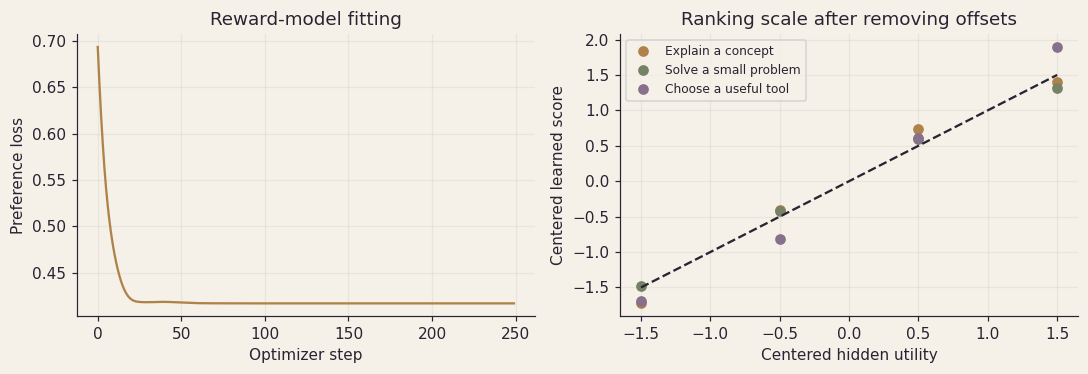

In [3]:
reward_scores = nn.Parameter(torch.zeros_like(UTILITY))
optimizer = torch.optim.Adam([reward_scores], lr=0.08)
reward_losses = []
p, winner, loser = train_pairs
for _ in range(250):
    differences = reward_scores[p, winner] - reward_scores[p, loser]
    loss = -nn.functional.logsigmoid(differences).mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    reward_losses.append(loss.item())

with torch.no_grad():
    tp, tw, tl = test_pairs
    heldout_margin = reward_scores[tp, tw] - reward_scores[tp, tl]
    heldout_loss = -nn.functional.logsigmoid(heldout_margin).mean().item()
    heldout_accuracy = (heldout_margin > 0).float().mean().item()
    oracle_accuracy = (UTILITY[tp, tw] > UTILITY[tp, tl]).float().mean().item()
    centered_scores = reward_scores - reward_scores.mean(dim=1, keepdim=True)
    centered_utility = UTILITY - UTILITY.mean(dim=1, keepdim=True)
print(f'Held-out preference loss: {heldout_loss:.3f}')
print(f'Held-out agreement: learned ranking {heldout_accuracy:.1%}, utility ranking {oracle_accuracy:.1%}')
print('The utility ranking is not 100% accurate against noisy sampled labels.')
assert reward_losses[-1] < reward_losses[0]
assert torch.isfinite(reward_scores).all()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(reward_losses)
axes[0].set(xlabel='Optimizer step', ylabel='Preference loss', title='Reward-model fitting')
for i in range(N_PROMPTS):
    axes[1].plot(centered_utility[i].numpy(), centered_scores[i].numpy(), 'o', label=PROMPTS[i])
axes[1].plot([-1.5, 1.5], [-1.5, 1.5], '--', color=INK)
axes[1].set(xlabel='Centered hidden utility', ylabel='Centered learned score', title='Ranking scale after removing offsets')
axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Common evaluation for policy optimization

Because the action space is tiny, we can calculate expected hidden utility and KL divergence
to the reference exactly. This avoids confusing Monte Carlo noise with actual policy changes.
The reference is frozen throughout both experiments. Higher hidden utility is desirable **by
construction in this toy dataset**; it is not a universal measure of answer quality.

In [4]:
def policy_metrics(logits):
    """Exact mean utility and forward KL, averaging the three prompts uniformly."""
    with torch.no_grad():
        logp = logits.log_softmax(dim=-1)
        probs = logp.exp()
        utility = (probs * UTILITY).sum(dim=-1).mean().item()
        kl = (probs * (logp - REFERENCE_LOGP)).sum(dim=-1).mean().item()
    return utility, kl

reference_metrics = policy_metrics(REFERENCE_LOGITS)
print('Reference expected utility / KL:', reference_metrics)
assert abs(reference_metrics[1]) < 1e-7

Reference expected utility / KL: (0.46093693375587463, 0.0)


## 4. DPO uses preference pairs directly

```text
margin = log(pi(winner)/reference(winner)) - log(pi(loser)/reference(loser))
DPO loss = -mean(log sigmoid(beta * margin))
```

The reward model from section 2 is **not** an input to this loss. DPO trains directly from
the fixed preference pairs and frozen reference. Increasing the reference-relative margin
does not guarantee that the preferred response's absolute probability rises on every update.
See the [original DPO paper](https://arxiv.org/abs/2305.18290).

Here beta is the scale in DPO's preference margin. It has a theoretical relationship to
KL-regularized reward optimization; it is not simply an extra KL term added to this code.

In [5]:
def dpo_loss(logits, pairs, beta=0.5):
    prompt, winner, loser = pairs
    logp = logits.log_softmax(dim=-1)
    relative = logp - REFERENCE_LOGP
    margin = relative[prompt, winner] - relative[prompt, loser]
    return -nn.functional.logsigmoid(beta * margin).mean()

dpo_logits = nn.Parameter(REFERENCE_LOGITS.clone())
optimizer = torch.optim.Adam([dpo_logits], lr=0.05)
dpo_history, dpo_losses = [], []
for _ in range(160):
    loss = dpo_loss(dpo_logits, train_pairs)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    dpo_losses.append(loss.item())
    dpo_history.append(policy_metrics(dpo_logits))
assert dpo_losses[-1] < dpo_losses[0]
assert policy_metrics(dpo_logits)[0] > reference_metrics[0]
print('DPO final expected utility / KL:', policy_metrics(dpo_logits))
with torch.no_grad(): print('DPO held-out pair loss:', round(dpo_loss(dpo_logits, test_pairs).item(), 3))

DPO final expected utility / KL: (1.7931537628173828, 0.897780179977417)
DPO held-out pair loss: 0.472


## 5. Group-relative advantages

For every sampled prompt, draw a group of candidate responses under the current old policy.
Score them with hidden utility, then subtract that group's mean and divide by its population
standard deviation plus epsilon. This compares responses to other attempts at the **same prompt**.

If every response gets the same score, all reward-based advantages are zero. That group
provides no ranking signal, although a separate reference KL penalty can still produce a gradient.
The original [DeepSeekMath paper](https://arxiv.org/abs/2402.03300) introduced GRPO to avoid a
separately trained value model while using group-relative policy optimization.

Our exercise uses one action per response, clipped ratios, and an **exact categorical forward
KL** penalty. Production implementations have token-level objectives and may use sampled KL
estimators, different normalization, or different loss aggregation. This is an explicitly
simplified group-relative experiment rather than a reproduction of that training system.

In [6]:
def group_advantages(rewards):
    """Normalize within each prompt group; never mix different prompts' rewards."""
    mean = rewards.mean(dim=-1, keepdim=True)
    std = rewards.std(dim=-1, keepdim=True, unbiased=False)
    return (rewards - mean) / (std + 1e-8)

assert torch.allclose(group_advantages(torch.tensor([[0., 1., 1., 0.]])),
                      torch.tensor([[-1., 1., 1., -1.]]))
assert torch.equal(group_advantages(torch.ones(2, 4)), torch.zeros(2, 4))
print('Group normalization handles both mixed and tied rewards.')

Group normalization handles both mixed and tied rewards.


In [7]:
def train_group_relative(seed, updates=90, groups=32, group_size=8, inner_epochs=3, kl_beta=0.04):
    """Toy one-step GRPO-style update; each outer iteration collects fresh groups."""
    torch.manual_seed(seed)
    logits = nn.Parameter(REFERENCE_LOGITS.clone())
    optimizer = torch.optim.Adam([logits], lr=0.04)
    history, zero_signal_rates = [], []
    for _ in range(updates):
        with torch.no_grad():
            prompts = torch.randint(N_PROMPTS, (groups,))
            old_logp = logits.log_softmax(dim=-1).detach().clone()
            old_probs = old_logp[prompts].exp()
            responses = torch.multinomial(old_probs, group_size, replacement=True)
            rewards = UTILITY[prompts[:, None], responses]
            advantages = group_advantages(rewards).detach()
            old_selected = old_logp[prompts].gather(1, responses)
            zero_signal_rates.append((advantages.abs().sum(dim=1) == 0).float().mean().item())
        for _ in range(inner_epochs):
            logp = logits.log_softmax(dim=-1)
            selected = logp[prompts].gather(1, responses)
            ratios = (selected - old_selected).exp()
            clipped = ratios.clamp(0.8, 1.2)
            surrogate = torch.minimum(ratios * advantages, clipped * advantages).mean()
            exact_kl = (logp.exp() * (logp - REFERENCE_LOGP)).sum(dim=-1).mean()
            loss = -surrogate + kl_beta * exact_kl
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_([logits], 1.0)
            optimizer.step()
        history.append(policy_metrics(logits))
    return logits.detach(), np.array(history), np.array(zero_signal_rates)

SEEDS = [7, 19, 31]
grpo_runs = [train_group_relative(seed) for seed in SEEDS]
for seed, (logits, history, _) in zip(SEEDS, grpo_runs):
    utility, kl = policy_metrics(logits)
    assert utility > reference_metrics[0]
    assert np.isfinite(history).all()
    print(f'Group-relative seed {seed}: expected utility {utility:.3f}, KL {kl:.3f}')

Group-relative seed 7: expected utility 1.990, KL 1.391
Group-relative seed 19: expected utility 1.990, KL 1.391
Group-relative seed 31: expected utility 1.991, KL 1.394


## 6. Compare objectives and inspect the learned distributions

The horizontal axes below count different operations: a DPO step uses a fixed dataset;
a group-relative outer cycle collects new samples and performs several updates. These are
learning diagnostics, **not a compute-matched efficiency comparison**. DPO is deterministic
for this fixed dataset and initialization; group-relative curves show three sampling seeds.

The learned reward model is kept separate to illustrate its role. We do not claim to implement
a full PPO-based RLHF pipeline here; the actual actor–critic optimizer is covered in notebook 6.

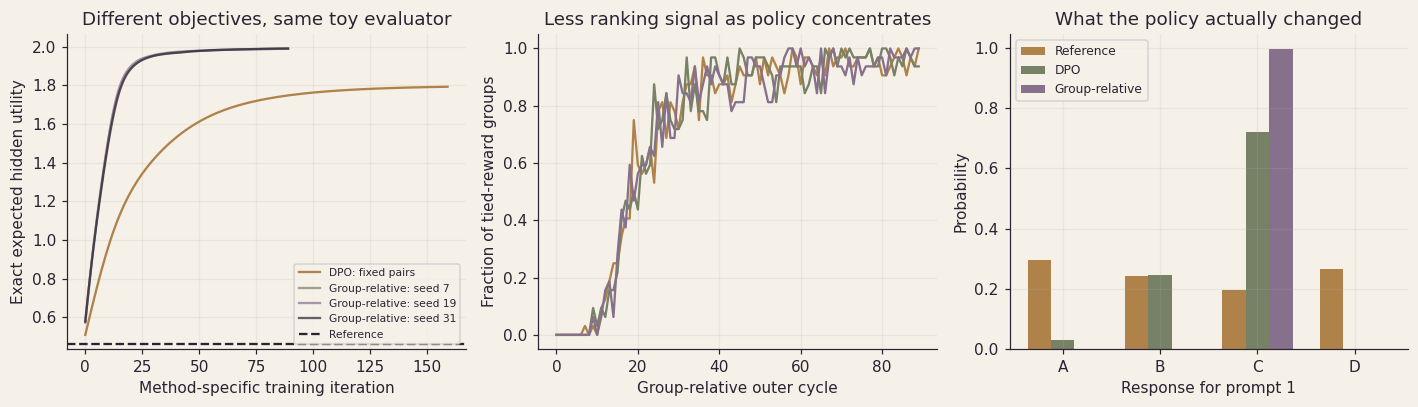

In [8]:
dpo_history = np.array(dpo_history)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(dpo_history[:, 0], label='DPO: fixed pairs')
for seed, (_, history, zeros) in zip(SEEDS, grpo_runs):
    axes[0].plot(history[:, 0], alpha=0.7, label=f'Group-relative: seed {seed}')
    axes[1].plot(zeros, label=f'Seed {seed}')
axes[0].axhline(reference_metrics[0], ls='--', color=INK, label='Reference')
axes[0].set(xlabel='Method-specific training iteration', ylabel='Exact expected hidden utility', title='Different objectives, same toy evaluator')
axes[0].legend(fontsize=7)
axes[1].set(xlabel='Group-relative outer cycle', ylabel='Fraction of tied-reward groups', title='Less ranking signal as policy concentrates')
with torch.no_grad():
    policies = [REFERENCE_LOGITS.softmax(-1), dpo_logits.softmax(-1), grpo_runs[0][0].softmax(-1)]
    for i, (name, probs) in enumerate(zip(['Reference', 'DPO', 'Group-relative'], policies)):
        axes[2].bar(np.arange(N_RESPONSES)+(i-1)*0.24, probs[0].numpy(), width=0.24, label=name)
axes[2].set(xticks=range(N_RESPONSES), xticklabels=['A', 'B', 'C', 'D'], xlabel='Response for prompt 1', ylabel='Probability', title='What the policy actually changed')
axes[2].legend(fontsize=8); plt.tight_layout(); plt.show()

| Method | Feedback consumed by its update | Separate reward model required here? | New online responses? |
| --- | --- | --- | --- |
| Pairwise reward model | Preferred/rejected pairs | It is the reward model | No |
| DPO | Preferred/rejected pairs and reference log probabilities | No | No |
| Toy group-relative policy optimization | Sampled response utilities and reference policy | No; this task has a direct scorer | Yes |

Replacing hidden utility with learned scores would expose reward-model errors to optimization.
Always evaluate against something beyond the optimized proxy. Group normalization alone is
not a complete policy algorithm: the sampling policy, probability ratios, objective, reference,
and update schedule also matter.

## Exercises

1. Add a constant to every reward-model score for one prompt. Do preference probabilities change?
2. Increase DPO beta and compare reference KL at convergence.
3. Use groups of size 2, 8, and 32. Inspect tied-group rates.
4. Score online samples with the learned reward table instead of hidden utility, while still evaluating hidden utility.
5. Add a response with an artificially inflated learned score and observe reward hacking.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. Pairwise score differences stay unchanged.
2. Interpret beta through the reference-relative margin; finite optimization and data noise matter.
3. Small groups can contain fewer useful comparisons, particularly when sampling concentrates.
4. Detach learned scores during the policy update; keep the evaluator independent.
5. A policy can exploit a high proxy score even when hidden utility is poor.

</details>

## What to remember

Preference learning, direct preference optimization, and online reward optimization have different data flows. Small categorical experiments make their assumptions inspectable, but do not substitute for evaluation of real language-model behavior.

## Further reading

- Rafailov et al., [Direct Preference Optimization](https://arxiv.org/abs/2305.18290).
- Shao et al., [DeepSeekMath: introducing GRPO](https://arxiv.org/abs/2402.03300).
- Ouyang et al., [Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155).

[← Previous notebook](06_ppo.ipynb)